In [4]:
import os
import numpy as np
from tqdm import tqdm
from nltk.stem.porter import PorterStemmer

import matplotlib.pyplot as plt
import re
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.feature_extraction.text import TfidfVectorizer
import gensim
from nltk.corpus import stopwords
from sklearn.preprocessing import Normalizer


from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import pandas as pd

from sklearn.preprocessing import MaxAbsScaler
from sklearn.metrics import precision_score, recall_score, f1_score, make_scorer
from sklearn.model_selection import cross_validate, StratifiedKFold
from sklearn.svm import LinearSVC
from xgboost import XGBClassifier
from sklearn.tree import DecisionTreeClassifier

# Loading Dataset, Stemming and Duplicates Removal

In [5]:
RAW_CSV_DIR = "data/df.csv"
CLEAN_CSV_DIR = "data/cleaned_df.csv"

custom_stopwords = [
    'cabl', 'news', 'daili', 'fri', 'aug', 'wed', 'thu', 'mon', 'tue', 'top', 'receiv', 'network', 'email',
    'thi', 'wa', 'ha', 'hi', 'ani', 'onli', 'use', 'will', 'need', 'know', 'make', 'one', 'say', 'look',
    'go', 'time', 'pleas', 'thank', 'now', 'want', 'said', 'new', 'may', 'work', 'inform', 'even', 'get',
    'see', 'right', 'also', 'much', 'day', 'year', 'b', 'x', 'c', 'e', 'u', 'v', 'p', 'lp', 'co', 'com',
    'http', 'www', 'compani', 'atlanta', 'georgia', 'cnncom', 'lllp', 'reserv', 'prefer', 'enron', 'ect',
    'hou', 'cnn', 'stat', 'ethz', 'ch', 'html'
]

ps = PorterStemmer()

english_stopwords = set(stopwords.words('english'))
custom_stopwords_set = set(custom_stopwords)

def clean_spam_text(text):
    if not isinstance(text, str):
        return ""

    text = re.sub('[^a-zA-Z]', ' ', text)

    words = text.lower().split()

    cleaned_words = []
    for w in words:
        if w in english_stopwords:
            continue

        stemmed_w = ps.stem(w)

        if stemmed_w in custom_stopwords_set:
            continue

        cleaned_words.append(stemmed_w)


    return ' '.join(cleaned_words)

if os.path.exists(CLEAN_CSV_DIR):
    print(f"Found existing cleaned dataset at {CLEAN_CSV_DIR}. Loading instantly...")
    df = pd.read_csv(CLEAN_CSV_DIR)

else:
    print(f"Cleaned dataset not found. Loading raw data from {RAW_CSV_DIR}...")
    df = pd.read_csv(RAW_CSV_DIR)
    df = df.dropna(subset=['text'])

    tqdm.pandas(desc="Cleaning Text")
    df['cleaned_text'] = df['text'].progress_apply(clean_spam_text)

    df['cleaned_text'] = (
        df['cleaned_text']
        .str.replace(r'\S*(escapelong|escapenumb|mailcom|httpwww)\S*', '', regex=True, flags=re.IGNORECASE)
        .str.replace(r'\s+', ' ', regex=True)
        .str.strip()
    )

    df = df.dropna(subset=['cleaned_text', 'label'])
    df = df[df['cleaned_text'].astype(str).str.strip() != '']

    print(f"Shape before dropping duplicates: {df.shape}")

    df = df.drop_duplicates(subset=['cleaned_text', 'label'], keep='first')

    label_counts = df.groupby('cleaned_text')['label'].nunique()

    # Find text that has more than 1 label
    conflicts = label_counts[label_counts > 1]

    print(f"Number of texts with conflicting labels: {len(conflicts)}")

    ambiguous_texts = conflicts.index
    df = df[~df['cleaned_text'].isin(ambiguous_texts)]

    print(f"Final clean shape after removing ambiguity: {df.shape}")

    df.to_csv(CLEAN_CSV_DIR, index=False)
    print("Saved successfully!")

print(f"Dataset ready! Shape: {df.shape}")


Found existing cleaned dataset at data/cleaned_df.csv. Loading instantly...
Dataset ready! Shape: (212859, 3)


# Dataset Split, Train and Test Base Model (Naive Bayes with Bow)

In [6]:
X = df['cleaned_text']
y = df['label'] # 0 -> ham, 1 -> phish, 2 -> spam

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

text_clf = Pipeline([
    ('vect', CountVectorizer(min_df=2, max_df=0.7)),
    ('clf', MultinomialNB())
])

print("Training Naive Bayes model...")
text_clf.fit(X_train, y_train)

predictions = text_clf.predict(X_test)

print("\n--- Classification Report ---")
print(classification_report(y_test, predictions))

Training Naive Bayes model...

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.94      0.96      0.95     18641
           1       0.74      0.65      0.69      8429
           2       0.79      0.82      0.81     15502

    accuracy                           0.85     42572
   macro avg       0.82      0.81      0.82     42572
weighted avg       0.85      0.85      0.85     42572



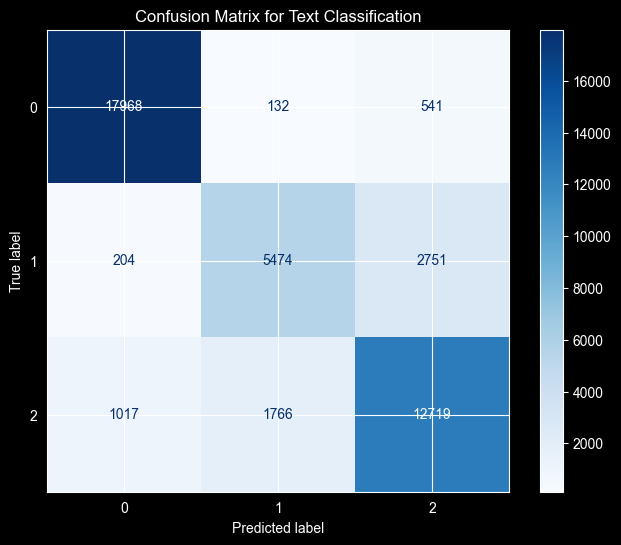

In [7]:
_, ax = plt.subplots(figsize=(8, 6))

cmd = ConfusionMatrixDisplay.from_estimator(
    text_clf, 
    X_test, 
    y_test, 
    display_labels=text_clf.classes_,
    cmap=plt.cm.Blues,
    ax=ax
)

plt.title('Confusion Matrix for Text Classification')
plt.show()

# Training Word2Vec to get Word Embeddings

In [8]:
print("--- Dense Representation (Word2Vec) ---")

# Word2Vec requires a list of words for each email
sentences = [str(text).split() for text in X_train]

print("Training Word2Vec model (this takes a moment)...")
w2v_model = gensim.models.Word2Vec(sentences, vector_size=100, window=5, min_count=2, workers=4)

# function to average the word vectors for a single email
def get_document_vector(doc):
    words = str(doc).split()
    word_vecs = [w2v_model.wv[word] for word in words if word in w2v_model.wv]
    if len(word_vecs) == 0:
        return np.zeros(100)
    return np.mean(word_vecs, axis=0)

print("Converting text to dense vectors...")
X_train_dense = np.array([get_document_vector(text) for text in X_train])
X_test_dense = np.array([get_document_vector(text) for text in X_test])

print(f"Dense Feature Space Size: {X_train_dense.shape[1]} dimensions")


--- Dense Representation (Word2Vec) ---
Training Word2Vec model (this takes a moment)...
Converting text to dense vectors...
Dense Feature Space Size: 100 dimensions


# Cross Validation with Several Models that Uses BoW as Feature Extraction Method



In [9]:
models = {
    "Naive Bayes" : Pipeline([
        ('vectorizer', CountVectorizer(min_df=2, max_df=0.7)),
        ('classifier', MultinomialNB()),
    ]),
    "Logistic Regression" : Pipeline([
        ('vectorizer', CountVectorizer(min_df=2, max_df=0.7)),
        ('scaler', MaxAbsScaler()),
        ('classifier', LogisticRegression(max_iter=1000, random_state=42))
    ]),
    "SVM" : Pipeline([
        ('vectorizer', CountVectorizer(min_df=2, max_df=0.7)),
        ('scaler', MaxAbsScaler()),
        ('classifier', LinearSVC(random_state=42, max_iter=2000))
    ]),


}

results_bow = []
scoring = {
    'accuracy': 'accuracy',

    'precision_c0': make_scorer(precision_score,
                               labels=[0],
                               average='macro'),

    'recall_c0': make_scorer(recall_score,
                            labels=[0],
                            average='macro'),

    'f1_c0': make_scorer(f1_score,
                        labels=[0],
                        average='macro')
}

for name, model in models.items():
    print(f"\nCross Validation for {name}...")
    cv_results = cross_validate(model, X_train, y_train,
                                cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42), scoring=scoring,
                                n_jobs=-1)

    results_bow.append({
        "Model": name,
        "Accuracy": f"{cv_results['test_accuracy'].mean():.3f} ± {cv_results['test_accuracy'].std():.3f}",
        "F1_Class0": f"{cv_results['test_f1_c0'].mean():.3f} ± {cv_results['test_f1_c0'].std():.3f}",
        "Recall_Class0": f"{cv_results['test_recall_c0'].mean():.3f} ± {cv_results['test_recall_c0'].std():.3f}",
        "Precision_Class0": f"{cv_results['test_precision_c0'].mean():.3f} ± {cv_results['test_precision_c0'].std():.3f}"
    })

results_df = pd.DataFrame(results_bow).set_index("Model")
print("\n=============================")
print("CROSS VALIDATION RESULTS FOR BOW")
print("=============================")

print(results_df.sort_values(by="F1_Class0", ascending=False))


Cross Validation for Naive Bayes...

Cross Validation for Logistic Regression...

Cross Validation for SVM...

CROSS VALIDATION RESULTS FOR BOW
                          Accuracy      F1_Class0  Recall_Class0  \
Model                                                              
SVM                  0.853 ± 0.001  0.953 ± 0.003  0.980 ± 0.002   
Naive Bayes          0.850 ± 0.002  0.952 ± 0.001  0.966 ± 0.002   
Logistic Regression  0.846 ± 0.002  0.938 ± 0.003  0.986 ± 0.002   

                    Precision_Class0  
Model                                 
SVM                    0.927 ± 0.007  
Naive Bayes            0.938 ± 0.002  
Logistic Regression    0.895 ± 0.006  


# Cross Validation with Several Models that Uses TFIDF as Feature Extraction Method

In [12]:
models = {
    "Naive Bayes" : Pipeline([
        ('vectorizer', TfidfVectorizer(min_df=2, max_df=0.7)),
        ('classifier', MultinomialNB()),
    ]),
    "Logistic Regression" : Pipeline([
        ('vectorizer', TfidfVectorizer(min_df=2, max_df=0.7)),
        ('classifier', LogisticRegression(max_iter=1000, random_state=42))
    ]),
    "SVM" : Pipeline([
        ('vectorizer', TfidfVectorizer(min_df=2, max_df=0.7)),
        ('classifier', LinearSVC(random_state=42, max_iter=2000))
    ]),


}


results_tfidf = []
scoring = {
    'accuracy': 'accuracy',

    'precision_c0': make_scorer(precision_score,
                               labels=[0],
                               average='macro',
                               zero_division=0),

    'recall_c0': make_scorer(recall_score,
                            labels=[0],
                            average='macro',
                            zero_division=0),

    'f1_c0': make_scorer(f1_score,
                        labels=[0],
                        average='macro',
                        zero_division=0)
}

for name, model in models.items():
    print(f"\nCross Validation for {name}...")
    cv_results = cross_validate(model, X_train, y_train,
                                cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42), scoring=scoring,
                                n_jobs=-1)

    results_tfidf.append({
        "Model": name,
        "Accuracy": f"{cv_results['test_accuracy'].mean():.3f} ± {cv_results['test_accuracy'].std():.3f}",
        "F1_Class0": f"{cv_results['test_f1_c0'].mean():.3f} ± {cv_results['test_f1_c0'].std():.3f}",
        "Recall_Class0": f"{cv_results['test_recall_c0'].mean():.3f} ± {cv_results['test_recall_c0'].std():.3f}",
        "Precision_Class0": f"{cv_results['test_precision_c0'].mean():.3f} ± {cv_results['test_precision_c0'].std():.3f}"
    })

results_df = pd.DataFrame(results_tfidf).set_index("Model")
print("\n=============================")
print("CROSS VALIDATION RESULTS FOR TFIDF")
print("=============================")

print(results_df.sort_values(by="F1_Class0", ascending=False))


Cross Validation for Naive Bayes...

Cross Validation for Logistic Regression...

Cross Validation for SVM...

CROSS VALIDATION RESULTS FOR TFIDF
                          Accuracy      F1_Class0  Recall_Class0  \
Model                                                              
SVM                  0.890 ± 0.002  0.979 ± 0.001  0.979 ± 0.001   
Logistic Regression  0.894 ± 0.002  0.973 ± 0.001  0.972 ± 0.001   
Naive Bayes          0.855 ± 0.001  0.946 ± 0.001  0.983 ± 0.001   

                    Precision_Class0  
Model                                 
SVM                    0.979 ± 0.002  
Logistic Regression    0.975 ± 0.002  
Naive Bayes            0.913 ± 0.002  


# Cross Validation with Several Models that Uses Word Embeddings as Feature Extraction Method

In [17]:

models = {
    "Logistic Regression": Pipeline([
        ('norm', Normalizer(norm='l2')),
        ('clf', LogisticRegression(max_iter=1000, random_state=42))
    ]),

    "SVM": Pipeline([
        ('norm', Normalizer(norm='l2')),
        ('clf', LinearSVC(random_state=42, max_iter=2000))
    ]),

    "Random Forest": Pipeline([
        ('clf', RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1))
    ]),

    "Decision Tree": Pipeline([
        ('clf', DecisionTreeClassifier(random_state=42))
    ]),

    "XGBoost": Pipeline([
        ('clf', XGBClassifier(random_state=42))
    ]),

    "MLP (Neural Net)": Pipeline([
        ('norm', Normalizer(norm='l2')),
        ('clf', MLPClassifier(
            hidden_layer_sizes=(100, 50),
            max_iter=500,
            activation='relu',
            solver='adam',
            random_state=42,
            early_stopping=True
        ))
    ])
}

results_dense = []

scoring = {
    'accuracy': 'accuracy',
    'precision_c0': make_scorer(precision_score, labels=[0], average='macro'),
    'recall_c0': make_scorer(recall_score, labels=[0], average='macro'),
    'f1_c0': make_scorer(f1_score, labels=[0], average='macro')
}

for name, model in models.items():
    print(f"Running Cross-Validation for {name}...")

    cv_results = cross_validate(
        model,
        X_train_dense,
        y_train,
        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
        scoring=scoring,
        n_jobs=-1
    )

    results_dense.append({
        "Model": name,
        "Accuracy": f"{cv_results['test_accuracy'].mean():.3f} ± {cv_results['test_accuracy'].std():.3f}",
        "F1_Class0": f"{cv_results['test_f1_c0'].mean():.3f} ± {cv_results['test_f1_c0'].std():.3f}",
        "Recall_Class0": f"{cv_results['test_recall_c0'].mean():.3f} ± {cv_results['test_recall_c0'].std():.3f}",
        "Precision_Class0": f"{cv_results['test_precision_c0'].mean():.3f} ± {cv_results['test_precision_c0'].std():.3f}"
    })

results_df = pd.DataFrame(results_dense).set_index("Model")

print("\n=======================================================")
print("  CROSS VALIDATION RESULTS FOR DENSE VECTORS (Word2Vec)  ")
print("=======================================================")
print(results_df.sort_values(by="F1_Class0", ascending=False))

Running Cross-Validation for Logistic Regression...
Running Cross-Validation for SVM...
Running Cross-Validation for Random Forest...
Running Cross-Validation for Decision Tree...
Running Cross-Validation for XGBoost...
Running Cross-Validation for MLP (Neural Net)...

  CROSS VALIDATION RESULTS FOR DENSE VECTORS (Word2Vec)  
                          Accuracy      F1_Class0  Recall_Class0  \
Model                                                              
XGBoost              0.885 ± 0.002  0.973 ± 0.001  0.974 ± 0.001   
MLP (Neural Net)     0.885 ± 0.002  0.972 ± 0.002  0.972 ± 0.004   
Random Forest        0.874 ± 0.002  0.971 ± 0.001  0.977 ± 0.001   
Logistic Regression  0.810 ± 0.002  0.938 ± 0.001  0.946 ± 0.002   
SVM                  0.806 ± 0.002  0.933 ± 0.001  0.951 ± 0.002   
Decision Tree        0.811 ± 0.002  0.932 ± 0.001  0.929 ± 0.002   

                    Precision_Class0  
Model                                 
XGBoost                0.972 ± 0.002  
MLP (Neura

# Testing the Best Model That Was Obtained from the Cross Validation with BoW

Training the best SVM model on the full training set...


C:\Users\tomas\anaconda3\envs\labs\Lib\site-packages\sklearn\svm\_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


Generating predictions on the test set...

      TEST PERFORMANCE RESULTS: SVM (BoW)      

              precision    recall  f1-score   support

           0       0.93      0.98      0.96     18641
           1       0.74      0.66      0.70      8429
           2       0.81      0.81      0.81     15502

    accuracy                           0.85     42572
   macro avg       0.83      0.82      0.82     42572
weighted avg       0.85      0.85      0.85     42572



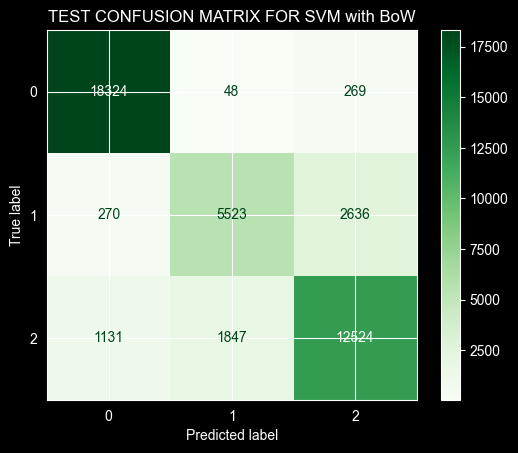

In [18]:
best_svm_pipeline = Pipeline([
    ('vectorizer', CountVectorizer(min_df=2, max_df=0.7)),
    ('scaler', MaxAbsScaler()),
    ('classifier', LinearSVC(random_state=42, max_iter=2000))
])


print("Training the best SVM model on the full training set...")
best_svm_pipeline.fit(X_train, y_train)


print("Generating predictions on the test set...")
y_pred_svm = best_svm_pipeline.predict(X_test)

print("\n=============================================")
print("      TEST PERFORMANCE RESULTS: SVM (BoW)      ")
print("=============================================\n")
print(classification_report(y_test, y_pred_svm))


ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_svm,
    display_labels=best_svm_pipeline.classes_,
    cmap='Greens'
)
plt.title('TEST CONFUSION MATRIX FOR SVM with BoW')
plt.show()

# Testing the Best Model That Was Obtained from the Cross Validation with TFIDF


TEST PERFORMANCE RESULTS SVM

              precision    recall  f1-score   support

           0       0.98      0.98      0.98     18641
           1       0.78      0.71      0.74      8429
           2       0.83      0.88      0.85     15502

    accuracy                           0.89     42572
   macro avg       0.87      0.86      0.86     42572
weighted avg       0.89      0.89      0.89     42572



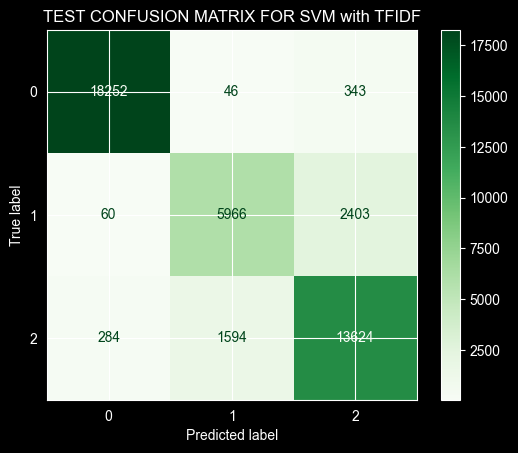

In [19]:
best_model_pipeline = Pipeline([
    ('vectorizer', TfidfVectorizer(min_df=2, max_df=0.7)),
    ('classifier', LinearSVC(random_state=42, max_iter=2000))
])

best_model_pipeline.fit(X_train, y_train)

y_pred = best_model_pipeline.predict(X_test)

print("\n=============================")
print("TEST PERFORMANCE RESULTS SVM")
print("=============================\n")
print(classification_report(y_test, y_pred))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=best_model_pipeline.classes_,
    cmap='Greens'
)
plt.title('TEST CONFUSION MATRIX FOR SVM with TFIDF')
plt.show()

# Testing the Best Model That Was Obtained from the Cross Validation with Word Embeddings (W2V)

Training the MLP model on the full training set (Word2Vec)...

TEST PERFORMANCE RESULTS MLP (Word2Vec)

              precision    recall  f1-score   support

           0       0.97      0.97      0.97     18641
           1       0.83      0.67      0.74      8429
           2       0.82      0.91      0.86     15502

    accuracy                           0.89     42572
   macro avg       0.88      0.85      0.86     42572
weighted avg       0.89      0.89      0.89     42572



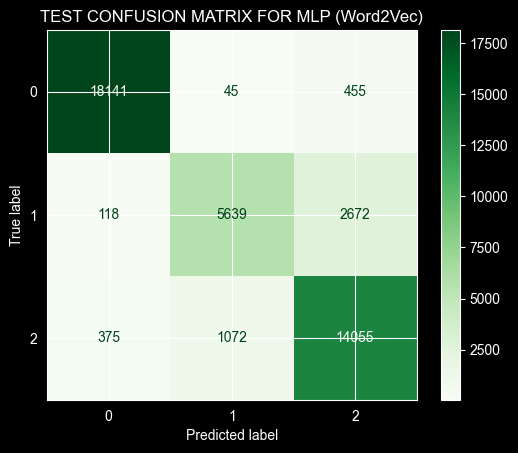

In [20]:
mlp_pipeline = Pipeline([
    ('norm', Normalizer(norm='l2')),
    ('classifier', MLPClassifier(
        hidden_layer_sizes=(100, 50),
        max_iter=500,
        activation='relu',
        solver='adam',
        random_state=42,
        early_stopping=True
    ))
])

print("Training the MLP model on the full training set (Word2Vec)...")
mlp_pipeline.fit(X_train_dense, y_train)

y_pred_mlp = mlp_pipeline.predict(X_test_dense)

print("\n=============================")
print("TEST PERFORMANCE RESULTS MLP (Word2Vec)")
print("=============================\n")
print(classification_report(y_test, y_pred_mlp))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_mlp,
    display_labels=mlp_pipeline.classes_,
    cmap='Greens'
)
plt.title('TEST CONFUSION MATRIX FOR MLP (Word2Vec)')
plt.show()

In [21]:
results_df = pd.DataFrame({
    'text': X_test,
    'actual': y_test,
    'predicted': y_pred
})

false_positives_c0 = results_df[(results_df['actual'] == 0) & (results_df['predicted'] != 0)]

print(f"Total False Positives for Class 0: {len(false_positives_c0)}")
print("\n--- Example Emails (Ham predicted as Spam/Phish) ---\n")

for index, row in false_positives_c0.head(15).iterrows():
    print(f"Predicted as: {row['predicted']}")
    print(f"Text: {row['text'][:500]}...")
    print("-" * 50)

Total False Positives for Class 0: 389

--- Example Emails (Ham predicted as Spam/Phish) ---

Predicted as: 2
Text: phone nrg powermarket call...
--------------------------------------------------
Predicted as: 2
Text: phazer org samuel...
--------------------------------------------------
Predicted as: 2
Text: full url...
--------------------------------------------------
Predicted as: 2
Text: friend yet anoth problem unabl solv keep messag unrecogn switch charact abort job past found caus misplac space dollar sign someth figur might sinc program abort find file record anywher might give might caus problem exampl job rtfpars scrambl file kept record kept somewher process abort jerri uiuc...
--------------------------------------------------
Predicted as: 2
Text: employe registr statement relat propos initi public offer share common stock tnpc inc tnpc affili corp file secur exchang commiss connect propos offer tnpc arrang limit number share tnpc common stock purchas employe certain in

### Error Analysis: Ham Misclassification
Vocabulary Overlap: Legitimate HR and promo emails use spam-heavy terms like "offer," "win," and "click."

Language Noise: Non-English emails create anomalies as they were not intended for this dataset.

Short Text Bias: Ultra-short emails (2-4 words) receive inflated TF-IDF weights, triggering false positives.


In [22]:
comparison_df = pd.DataFrame({
    'original_text': df.loc[X_test.index, 'text'].values,
    'stemmed_text': X_test.values,
    'actual': y_test.values,
    'predicted_svm': y_pred_svm,
    'predicted_mlp': y_pred_mlp
})

disagreements = comparison_df[comparison_df['predicted_svm'] != comparison_df['predicted_mlp']]

print("=============================================")
print("       MODEL DISAGREEMENT METRICS            ")
print("=============================================\n")
print(f"Total Disagreements: {len(disagreements)} emails")


disagreement_matrix = pd.crosstab(
    disagreements['predicted_svm'],
    disagreements['predicted_mlp'],
    rownames=['SVM Predicted'],
    colnames=['MLP Predicted']
)
print("\n--- Disagreement Matrix ---")
print("Read as: SVM predicted [Row], but MLP predicted [Column]")
print(disagreement_matrix)

print("\n=============================================")
print("  READABLE EXAMPLES (MLP failed, SVM correct)  ")
print("=============================================\n")

svm_wins = comparison_df[(comparison_df['predicted_svm'] == comparison_df['actual']) &
                         (comparison_df['predicted_mlp'] != comparison_df['actual'])]

for index, row in svm_wins.head(3).iterrows():
    print(f"Actual: {row['actual']} | SVM: {row['predicted_svm']} | MLP: {row['predicted_mlp']}")
    print(f"Readable Text: {row['original_text'][:500]}...")
    print("-" * 60)

       MODEL DISAGREEMENT METRICS            

Total Disagreements: 5548 emails

--- Disagreement Matrix ---
Read as: SVM predicted [Row], but MLP predicted [Column]
MLP Predicted    0     1     2
SVM Predicted                 
0                0   245  1345
1               96     0  2135
2              403  1324     0

  READABLE EXAMPLES (MLP failed, SVM correct)  

Actual: 1 | SVM: 1 | MLP: 2
Readable Text: claims dear sir accept sincere apologies mail meet personal ethics introduce staff accounts management section well known bank republic benin one accounts holding balance 20 500 000 twenty million five hundred thousand united states dollars dormant operated past 9 months investigations confirmations owner account foreigner name mr ali yacoubou died unfortunately died plane crash union transport africaines flight boeing 727 cotonou benin republic december 25 2003 read crash visiting websites www ...
------------------------------------------------------------
Actual: 2 | SVM: 2 | 

# Conclusion
Harmless Disagreements: Over 50% of discrepancies are between Spam and Phishing. Since both are filtered as junk, these errors do not affect the user experience.

SVM (Vocabulary): Best at identifying safe corporate nouns but over-penalizes promotional keywords in legitimate mail.

MLP (Semantics): Best at detecting malicious tones but misidentifies urgent corporate notifications as Phishing.

